# ADD_STUDENT_DEGREE_STATUS clean notebook

This notebook cleans `ADD_STUDENT_DEGREE_STATUS` for academic advice and course recommendation work.

It assumes `df_raw` is already loaded. It does not read from a database, read parquet files, access credentials, train models, split data, or save parquet output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.paths import RAW_DIR
from src.cleaning_utils import integer_like_report, normalize_id_columns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")

## Table role and grain

`ADD_STUDENT_DEGREE_STATUS` stores one academic status row per student per semester.

Primary key: `student_status_id`.

Logical key: `student_id` + `part_id`.

`finish_status` and `finish_part_id` are kept for audit, filtering, and later outcome construction. They must not be used later as model input features because they describe final path-level outcomes and can leak future information.

In [2]:
df_raw = pd.read_parquet(RAW_DIR / "v_add_student_degree_status.parquet")
assert "df_raw" in globals(), "df_raw must already be loaded before running this notebook."

df = df_raw.copy()

normalized_columns = (
    pd.Index(df.columns)
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^0-9a-zA-Z_]+", "_", regex=True)
    .str.strip("_")
    .str.lower()
)

if normalized_columns.duplicated().any():
    duplicate_columns = normalized_columns[normalized_columns.duplicated()].tolist()
    raise ValueError(f"Column-name normalization created duplicate column names: {duplicate_columns}")

df.columns = normalized_columns

initial_rows = len(df)
print(f"Initial shape: {df.shape}")

Initial shape: (184530, 44)


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 184530 entries, 0 to 184529
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   student_status_id       184530 non-null  float64
 1   student_id              184530 non-null  float64
 2   part_id                 184530 non-null  float64
 3   degree_id               182404 non-null  float64
 4   start_part_id           184525 non-null  float64
 5   finish_part_id          117154 non-null  float64
 6   grade_version_id        184519 non-null  float64
 7   permanent_status_id     184530 non-null  float64
 8   permanent_status_sl     184530 non-null  str    
 9   study_mode              184530 non-null  str    
 10  prev_gpa_points         164485 non-null  float64
 11  prev_gpa_percent        164485 non-null  float64
 12  gpa_percent             184519 non-null  float64
 13  gpa_points              184519 non-null  float64
 14  start_agpa_percent      184519 

In [4]:
REQUIRED_COLUMNS = [
    "student_status_id",
    "student_id",
    "part_id",
    "degree_id",
    "start_part_id",
    "finish_part_id",
    "grade_version_id",
    "study_mode",
    "permanent_status_id",
    "prev_gpa_points",
    "prev_gpa_percent",
    "gpa_percent",
    "gpa_points",
    "start_agpa_percent",
    "start_agpa_points",
    "start_total_in_courses",
    "start_total_in_credits",
    "end_total_in_courses",
    "end_total_in_credits",
    "end_agpa_percent",
    "end_agpa_points",
    "semester_reg_courses",
    "semester_reg_credits",
    "semester_pass_courses",
    "semester_pass_credits",
    "semester_fail_courses",
    "semester_fail_credits",
    "semester_in_courses",
    "semester_in_credits",
    "total_semesters",
    "total_reg_courses",
    "total_reg_credits",
    "total_pass_courses",
    "total_pass_credits",
    "total_fail_courses",
    "total_fail_credits",
    "reg_total_semesters",
    "finish_status",
    "version_title_sl",
    "degree_name_sl",
    "degree_credits_count",
    "start_level_id",
    "start_level_name_pl",
]

missing_columns = [column for column in REQUIRED_COLUMNS if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print(f"All required columns are present: {len(REQUIRED_COLUMNS)} columns")

All required columns are present: 43 columns


## ID handling

Entity IDs can carry source-system suffixes such as `12345.111`, so they are normalized with the existing `src.cleaning_utils.normalize_id_columns` function and kept as strings.

Semester codes (`part_id`, `start_part_id`, `finish_part_id`) are not suffix-normalized. They are validated as integer-like semester codes and stored as nullable integers.

In [5]:
entity_id_columns = [
    "student_status_id",
    "student_id",
    "degree_id",
    "grade_version_id",
    "start_level_id",
]

semester_code_columns = [
    "part_id",
    "start_part_id",
    "finish_part_id",
]

status_code_columns = ["permanent_status_id"]

id_validation_report = pd.DataFrame(
    [integer_like_report(df, column) for column in entity_id_columns + semester_code_columns + status_code_columns]
)

print("ID and code validation report before conversion:")
display(id_validation_report)

df = normalize_id_columns(df, entity_id_columns)

for column in semester_code_columns + status_code_columns:
    numeric = pd.to_numeric(df[column], errors="coerce")
    source_has_value = df[column].notna() & df[column].astype("string").str.strip().ne("")

    invalid_values = source_has_value & numeric.isna()
    if invalid_values.any():
        examples = df.loc[invalid_values, column].drop_duplicates().head(10).tolist()
        raise ValueError(f"{column} contains non-numeric values. Examples: {examples}")

    non_integer_values = numeric.notna() & ~np.isclose(numeric % 1, 0, atol=1e-9)
    if non_integer_values.any():
        examples = df.loc[non_integer_values, column].drop_duplicates().head(10).tolist()
        raise ValueError(f"{column} contains non-integer values. Examples: {examples}")

    df[column] = numeric.round().astype("Int64")

id_dtype_report_after_cleaning = pd.DataFrame(
    {
        "column": entity_id_columns + semester_code_columns + status_code_columns,
        "dtype_after_cleaning": [str(df[column].dtype) for column in entity_id_columns + semester_code_columns + status_code_columns],
        "null_count_after_cleaning": [int(df[column].isna().sum()) for column in entity_id_columns + semester_code_columns + status_code_columns],
    }
)

print("ID and code dtypes after cleaning:")
display(id_dtype_report_after_cleaning)

ID and code validation report before conversion:


,column,source_dtype,non_null_count,numeric_count,non_numeric_or_null_count,fractional_count,fractional_ratio
0,student_status_id,float64,184530,184530,0,184530,1.0
1,student_id,float64,184530,184530,0,184530,1.0
2,degree_id,float64,182404,182404,2126,182404,1.0
3,grade_version_id,float64,184519,184519,11,184519,1.0
4,start_level_id,float64,181459,181459,3071,181459,1.0
5,part_id,float64,184530,184530,0,0,0.0
6,start_part_id,float64,184525,184525,5,0,0.0
7,finish_part_id,float64,117154,117154,67376,0,0.0
8,permanent_status_id,float64,184530,184530,0,0,0.0


ID and code dtypes after cleaning:


,column,dtype_after_cleaning,null_count_after_cleaning
0,student_status_id,string,0
1,student_id,string,0
2,degree_id,string,2126
3,grade_version_id,string,11
4,start_level_id,string,3071
5,part_id,Int64,0
6,start_part_id,Int64,5
7,finish_part_id,Int64,67376
8,permanent_status_id,Int64,0


In [6]:
text_columns = [
    "finish_status",
    "version_title_sl",
    "degree_name_sl",
    "start_level_name_pl",
]

for column in text_columns:
    cleaned = df[column].astype("string").str.strip()
    empty_like = cleaned.eq("") | cleaned.str.lower().isin(["nan", "none", "null", "<na>"])
    df[column] = cleaned.mask(empty_like, pd.NA)

numeric_columns = [
    "prev_gpa_points",
    "prev_gpa_percent",
    "gpa_points",
    "gpa_percent",
    "start_agpa_points",
    "start_agpa_percent",
    "end_agpa_points",
    "end_agpa_percent",
    "semester_reg_courses",
    "semester_reg_credits",
    "semester_pass_courses",
    "semester_pass_credits",
    "semester_fail_courses",
    "semester_fail_credits",
    "semester_in_courses",
    "semester_in_credits",
    "start_total_in_courses",
    "start_total_in_credits",
    "end_total_in_courses",
    "end_total_in_credits",
    "total_semesters",
    "reg_total_semesters",
    "total_reg_courses",
    "total_reg_credits",
    "total_pass_courses",
    "total_pass_credits",
    "total_fail_courses",
    "total_fail_credits",
    "degree_credits_count",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce").astype("Float64")

In [7]:
duplicate_student_status_count = int(df["student_status_id"].duplicated().sum())
duplicate_logical_key_count = int(df.duplicated(["student_id", "part_id"]).sum())

print(f"student_status_id is unique: {df['student_status_id'].is_unique}")
print(f"Duplicate student_status_id rows: {duplicate_student_status_count}")
print(f"Duplicate student_id + part_id rows: {duplicate_logical_key_count}")

duplicate_student_status_report = df.loc[df["student_status_id"].duplicated(keep=False)].sort_values("student_status_id")
duplicate_logical_key_report = df.loc[df.duplicated(["student_id", "part_id"], keep=False)].sort_values(["student_id", "part_id"])

if duplicate_student_status_count > 0:
    print("Duplicate student_status_id rows:")
    display(duplicate_student_status_report)

if duplicate_logical_key_count > 0:
    print("Duplicate student_id + part_id rows:")
    display(duplicate_logical_key_report)

if duplicate_student_status_count > 0 or duplicate_logical_key_count > 0:
    raise ValueError("Duplicate key values found. This violates the expected table grain.")

student_status_id is unique: True
Duplicate student_status_id rows: 0
Duplicate student_id + part_id rows: 0


In [8]:
df['student_id'].nunique()

20122

In [9]:
initial_null_report = (
    pd.DataFrame(
        {
            "column": df.columns,
            "dtype": [str(dtype) for dtype in df.dtypes],
            "null_count": [int(df[column].isna().sum()) for column in df.columns],
            "null_percent": [round(float(df[column].isna().mean() * 100), 4) for column in df.columns],
        }
    )
    .sort_values(["null_count", "column"], ascending=[False, True])
    .reset_index(drop=True)
)

initial_null_report

,column,dtype,null_count,null_percent
0,finish_part_id,Int64,67376,36.5122
1,finish_status,string,67060,36.3410
2,prev_gpa_percent,Float64,20045,10.8627
3,prev_gpa_points,Float64,20045,10.8627
4,start_level_id,string,3071,1.6642
5,degree_credits_count,Float64,2126,1.1521
6,degree_id,string,2126,1.1521
7,degree_name_sl,string,2126,1.1521
8,reg_total_semesters,Float64,617,0.3344
9,end_agpa_percent,Float64,11,0.0060


## Cleaning rules

Preprocessing steps:

1. Drop `permanent_status_id` administrative incomplete registrations.
2. Drop `degree_id` null rows.
3. Drop `WITHDRAWN` students with one zero-activity record.
4. Drop core academic null rows.
5. Drop `study_mode` column.
6. Create `df_clean`.

Dropped rows:

- incomplete administrative registrations identified by `permanent_status_id`
- rows without `degree_id`
- `WITHDRAWN` students with exactly one row and no registered, passed, failed, GPA, or AGPA activity
- rows with nulls in the core academic columns

Intentionally kept:

- graduated students
- active/current students where `finish_status` is null
- withdrawn students with more than one record or any real academic activity
- close-file, cancel-admission, change-plan, change-degree, change-faculty, final-dismiss, and other remaining final statuses
- first-semester nulls in `prev_gpa_points` and `prev_gpa_percent`
- null `finish_part_id`
- `start_level_id` nulls when `start_level_name_pl` is available

In [10]:
EXCLUDED_PERMANENT_STATUS_IDS = [1, 4, 11, 12, 15, 16, 41]

CORE_ACADEMIC_COLUMNS = [
    "grade_version_id",
    "gpa_percent",
    "gpa_points",
    "start_agpa_percent",
    "start_agpa_points",
    "end_agpa_percent",
    "end_agpa_points",
    "semester_reg_courses",
    "semester_reg_credits",
    "semester_pass_courses",
    "semester_pass_credits",
    "semester_fail_courses",
    "semester_fail_credits",
    "semester_in_courses",
    "semester_in_credits",
    "total_semesters",
    "total_reg_courses",
    "total_reg_credits",
    "total_pass_courses",
    "total_pass_credits",
    "total_fail_courses",
    "total_fail_credits",
    "version_title_sl",
]

WITHDRAWN_ZERO_ACTIVITY_COLUMNS = [
    "gpa_points",
    "gpa_percent",
    "end_agpa_points",
    "end_agpa_percent",
    "total_reg_courses",
    "total_reg_credits",
    "total_pass_courses",
    "total_pass_credits",
    "total_fail_courses",
    "total_fail_credits",
]

FINAL_COLUMNS = [
    "student_status_id",
    "student_id",
    "part_id",
    "degree_id",
    "start_part_id",
    "finish_part_id",
    "grade_version_id",
    "prev_gpa_points",
    "prev_gpa_percent",
    "gpa_points",
    "gpa_percent",
    "start_agpa_points",
    "start_agpa_percent",
    "end_agpa_points",
    "end_agpa_percent",
    "semester_reg_courses",
    "semester_reg_credits",
    "semester_pass_courses",
    "semester_pass_credits",
    "semester_fail_courses",
    "semester_fail_credits",
    "semester_in_courses",
    "semester_in_credits",
    "start_total_in_courses",
    "start_total_in_credits",
    "end_total_in_courses",
    "end_total_in_credits",
    "total_semesters",
    "reg_total_semesters",
    "total_reg_courses",
    "total_reg_credits",
    "total_pass_courses",
    "total_pass_credits",
    "total_fail_courses",
    "total_fail_credits",
    "finish_status",
    "version_title_sl",
    "degree_name_sl",
    "degree_credits_count",
    "start_level_id",
    "start_level_name_pl",
]

In [11]:
rows_before_permanent_status = len(df)
permanent_status_drop_mask = df["permanent_status_id"].isin(EXCLUDED_PERMANENT_STATUS_IDS)

dropped_permanent_status_report = df.loc[permanent_status_drop_mask].copy()
df = df.loc[~permanent_status_drop_mask].copy()

rows_dropped_permanent_status = len(dropped_permanent_status_report)
rows_after_permanent_status_filter = len(df)

print(f"Rows before permanent_status_id filter: {rows_before_permanent_status}")
print(f"Rows dropped by permanent_status_id filter: {rows_dropped_permanent_status}")
print(f"Rows remaining after permanent_status_id filter: {rows_after_permanent_status_filter}")

Rows before permanent_status_id filter: 184530
Rows dropped by permanent_status_id filter: 2717
Rows remaining after permanent_status_id filter: 181813


In [12]:
rows_before_degree_null_drop = len(df)
degree_null_drop_mask = df["degree_id"].isna()

dropped_degree_null_report = df.loc[degree_null_drop_mask].copy()
df = df.loc[~degree_null_drop_mask].copy()

rows_dropped_degree_null = len(dropped_degree_null_report)
rows_after_degree_null_drop = len(df)

print(f"Rows before degree_id null drop: {rows_before_degree_null_drop}")
print(f"Rows dropped by degree_id null: {rows_dropped_degree_null}")
print(f"Rows remaining after degree_id null drop: {rows_after_degree_null_drop}")

Rows before degree_id null drop: 181813
Rows dropped by degree_id null: 93
Rows remaining after degree_id null drop: 181720


In [13]:
rows_before_withdrawn_single_zero_activity_drop = len(df)
student_row_counts = df.groupby("student_id", dropna=False)["student_id"].transform("size")
zero_activity_mask = df[WITHDRAWN_ZERO_ACTIVITY_COLUMNS].eq(0).fillna(False).all(axis=1)
withdrawn_single_zero_activity_drop_mask = (
    df["finish_status"].eq("WITHDRAWN").fillna(False)
    & student_row_counts.eq(1)
    & zero_activity_mask
)

dropped_withdrawn_single_zero_activity_report = df.loc[withdrawn_single_zero_activity_drop_mask].copy()
df = df.loc[~withdrawn_single_zero_activity_drop_mask].copy()

rows_dropped_withdrawn_single_zero_activity = len(dropped_withdrawn_single_zero_activity_report)
rows_after_withdrawn_single_zero_activity_drop = len(df)

print(f"Rows before withdrawn single zero-activity drop: {rows_before_withdrawn_single_zero_activity_drop}")
print(f"Rows dropped by withdrawn single zero-activity rule: {rows_dropped_withdrawn_single_zero_activity}")
print(f"Rows remaining after withdrawn single zero-activity drop: {rows_after_withdrawn_single_zero_activity_drop}")

Rows before withdrawn single zero-activity drop: 181720
Rows dropped by withdrawn single zero-activity rule: 168
Rows remaining after withdrawn single zero-activity drop: 181552


In [14]:
rows_before_core_null_drop = len(df)
core_null_drop_mask = df[CORE_ACADEMIC_COLUMNS].isna().any(axis=1)

dropped_core_null_report = df.loc[core_null_drop_mask].copy()
df = df.loc[~core_null_drop_mask].copy()

rows_dropped_core_null = len(dropped_core_null_report)
rows_after_core_academic_null_drop = len(df)

print(f"Rows before core academic null drop: {rows_before_core_null_drop}")
print(f"Rows dropped by core academic nulls: {rows_dropped_core_null}")
print(f"Rows remaining after core academic null drop: {rows_after_core_academic_null_drop}")

Rows before core academic null drop: 181552
Rows dropped by core academic nulls: 0
Rows remaining after core academic null drop: 181552


In [15]:
df = df.drop(columns=["study_mode"], errors="ignore")

print("Dropped study_mode column.")

Dropped study_mode column.


In [16]:
df_clean = df[FINAL_COLUMNS].copy()
final_rows = len(df_clean)

print(f"Final clean shape: {df_clean.shape}")

Final clean shape: (181552, 41)


In [17]:
duplicate_final_student_status_count = int(df_clean["student_status_id"].duplicated().sum())
duplicate_final_logical_key_count = int(df_clean.duplicated(["student_id", "part_id"]).sum())

if duplicate_final_student_status_count > 0:
    display(df_clean.loc[df_clean["student_status_id"].duplicated(keep=False)].sort_values("student_status_id"))
    raise ValueError(f"student_status_id must be unique. Duplicate row count: {duplicate_final_student_status_count}")

if duplicate_final_logical_key_count > 0:
    display(df_clean.loc[df_clean.duplicated(["student_id", "part_id"], keep=False)].sort_values(["student_id", "part_id"]))
    raise ValueError(f"student_id + part_id must be unique. Duplicate row count: {duplicate_final_logical_key_count}")

assert df_clean["degree_id"].notna().all(), "degree_id must have no nulls."
assert df_clean[CORE_ACADEMIC_COLUMNS].notna().all().all(), "Core academic columns must have no nulls."
assert "study_mode" not in df_clean.columns, "study_mode must not exist in df_clean."
assert "permanent_status_id" not in df_clean.columns, "permanent_status_id must not exist in df_clean."
assert list(df_clean.columns) == FINAL_COLUMNS, "df_clean does not contain exactly the selected final columns in order."

print("Final validation checks passed.")

Final validation checks passed.


In [18]:
cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "initial_rows",
            "rows_dropped_by_permanent_status_id",
            "rows_dropped_by_degree_id_null",
            "rows_dropped_by_withdrawn_single_zero_activity",
            "rows_dropped_by_core_academic_nulls",
            "final_rows",
            "final_columns_count",
        ],
        "value": [
            initial_rows,
            rows_dropped_permanent_status,
            rows_dropped_degree_null,
            rows_dropped_withdrawn_single_zero_activity,
            rows_dropped_core_null,
            final_rows,
            len(df_clean.columns),
        ],
    }
)

final_finish_status_distribution = df_clean["finish_status"].value_counts(dropna=False).rename("row_count").to_frame()

final_null_report = (
    pd.DataFrame(
        {
            "column": df_clean.columns,
            "dtype": [str(dtype) for dtype in df_clean.dtypes],
            "null_count": [int(df_clean[column].isna().sum()) for column in df_clean.columns],
            "null_percent": [round(float(df_clean[column].isna().mean() * 100), 4) for column in df_clean.columns],
        }
    )
    .sort_values(["null_count", "column"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Cleaning summary:")
display(cleaning_summary)

print("Final finish_status distribution after cleaning:")
display(final_finish_status_distribution)

print("Final null report after cleaning:")
display(final_null_report)

Cleaning summary:


,metric,value
0,initial_rows,184530
1,rows_dropped_by_permanent_status_id,2717
2,rows_dropped_by_degree_id_null,93
3,rows_dropped_by_withdrawn_single_zero_activity,168
4,rows_dropped_by_core_academic_nulls,0
5,final_rows,181552
6,final_columns_count,41


Final finish_status distribution after cleaning:


,row_count
finish_status,
GRADUATED,95220
<NA>,64255
CLOSE_FILE,14395
WITHDRAWN,4032
CHANGE_PLAN,1885
CANCEL_ADMISSION,604
FINAL_DISMISS,539
CHANGE_DEGREE,380
CHANGE_FACULTY,238


Final null report after cleaning:


,column,dtype,null_count,null_percent
0,finish_part_id,Int64,64571,35.5661
1,finish_status,string,64255,35.3921
2,prev_gpa_percent,Float64,17072,9.4034
3,prev_gpa_points,Float64,17072,9.4034
4,start_level_id,string,948,0.5222
5,reg_total_semesters,Float64,606,0.3338
6,degree_credits_count,Float64,0,0.0000
7,degree_id,string,0,0.0000
8,degree_name_sl,string,0,0.0000
9,end_agpa_percent,Float64,0,0.0000


## Simple validation plots

These plots are only for cleaning validation and basic data understanding. They do not create model features.

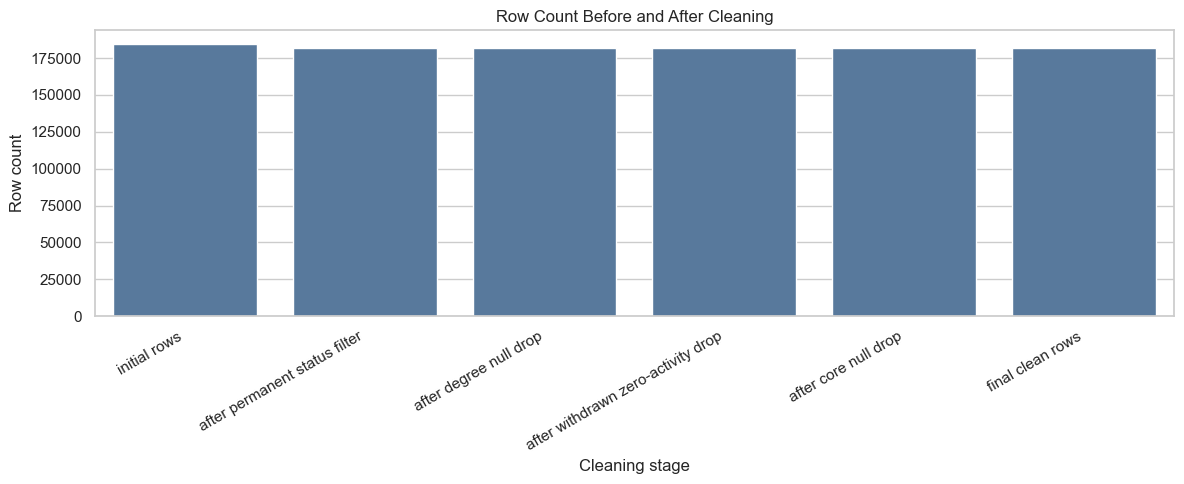

In [19]:
row_count_plot_data = pd.DataFrame(
    {
        "stage": [
            "initial rows",
            "after permanent status filter",
            "after degree null drop",
            "after withdrawn zero-activity drop",
            "after core null drop",
            "final clean rows",
        ],
        "row_count": [
            initial_rows,
            rows_after_permanent_status_filter,
            rows_after_degree_null_drop,
            rows_after_withdrawn_single_zero_activity_drop,
            rows_after_core_academic_null_drop,
            final_rows,
        ],
    }
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=row_count_plot_data, x="stage", y="row_count", color="#4C78A8", ax=ax)
ax.set_title("Row Count Before and After Cleaning")
ax.set_xlabel("Cleaning stage")
ax.set_ylabel("Row count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

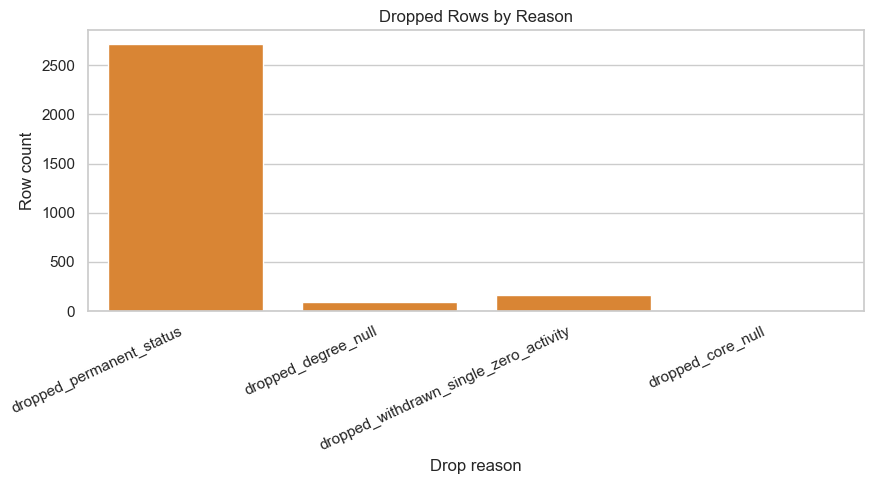

In [20]:
dropped_rows_plot_data = pd.DataFrame(
    {
        "reason": [
            "dropped_permanent_status",
            "dropped_degree_null",
            "dropped_withdrawn_single_zero_activity",
            "dropped_core_null",
        ],
        "row_count": [
            rows_dropped_permanent_status,
            rows_dropped_degree_null,
            rows_dropped_withdrawn_single_zero_activity,
            rows_dropped_core_null,
        ],
    }
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=dropped_rows_plot_data, x="reason", y="row_count", color="#F58518", ax=ax)
ax.set_title("Dropped Rows by Reason")
ax.set_xlabel("Drop reason")
ax.set_ylabel("Row count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

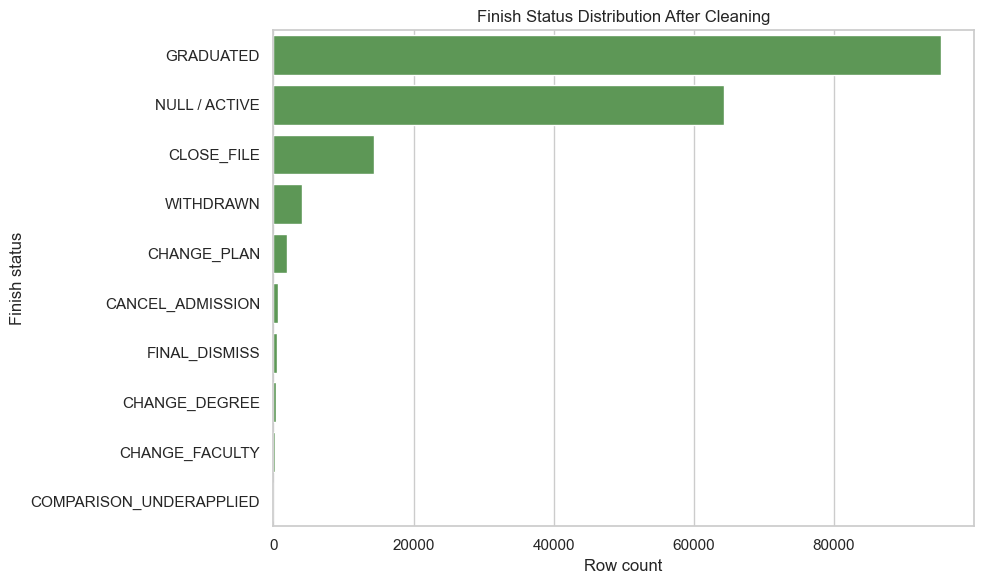

In [21]:
finish_status_plot_data = (
    df_clean["finish_status"]
    .fillna("NULL / ACTIVE")
    .astype("string")
    .value_counts(dropna=False)
    .rename_axis("finish_status")
    .reset_index(name="row_count")
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=finish_status_plot_data, y="finish_status", x="row_count", color="#54A24B", ax=ax)
ax.set_title("Finish Status Distribution After Cleaning")
ax.set_xlabel("Row count")
ax.set_ylabel("Finish status")
plt.tight_layout()
plt.show()

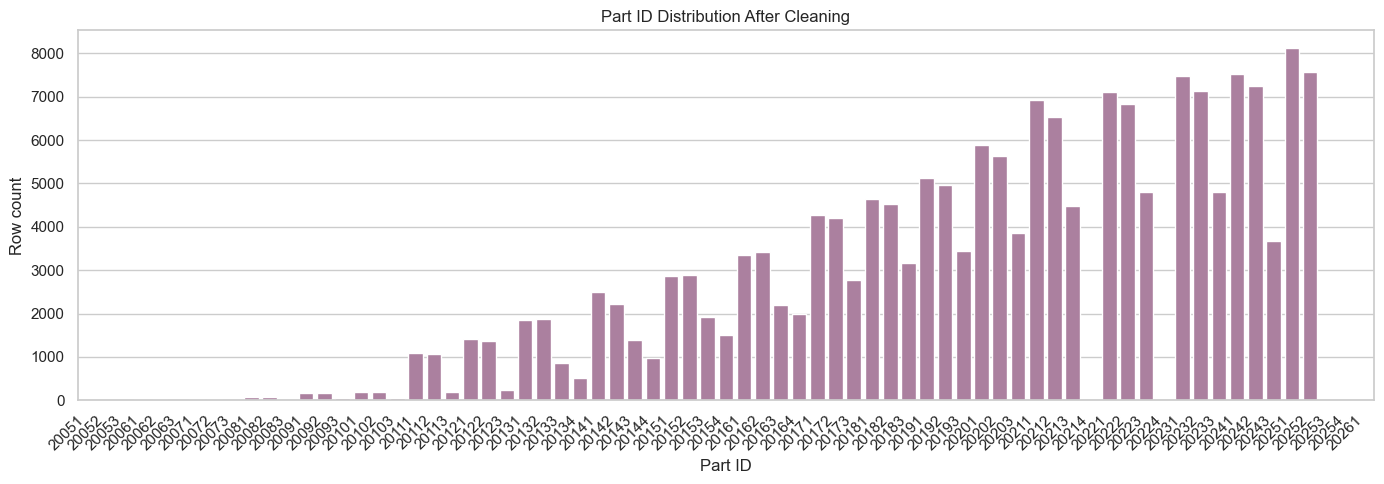

In [22]:
part_id_plot_data = (
    df_clean["part_id"]
    .value_counts(dropna=False)
    .rename_axis("part_id")
    .reset_index(name="row_count")
    .sort_values("part_id", na_position="last")
)
part_id_plot_data["part_id_label"] = part_id_plot_data["part_id"].astype("string")

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=part_id_plot_data, x="part_id_label", y="row_count", color="#B279A2", ax=ax)
ax.set_title("Part ID Distribution After Cleaning")
ax.set_xlabel("Part ID")
ax.set_ylabel("Row count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

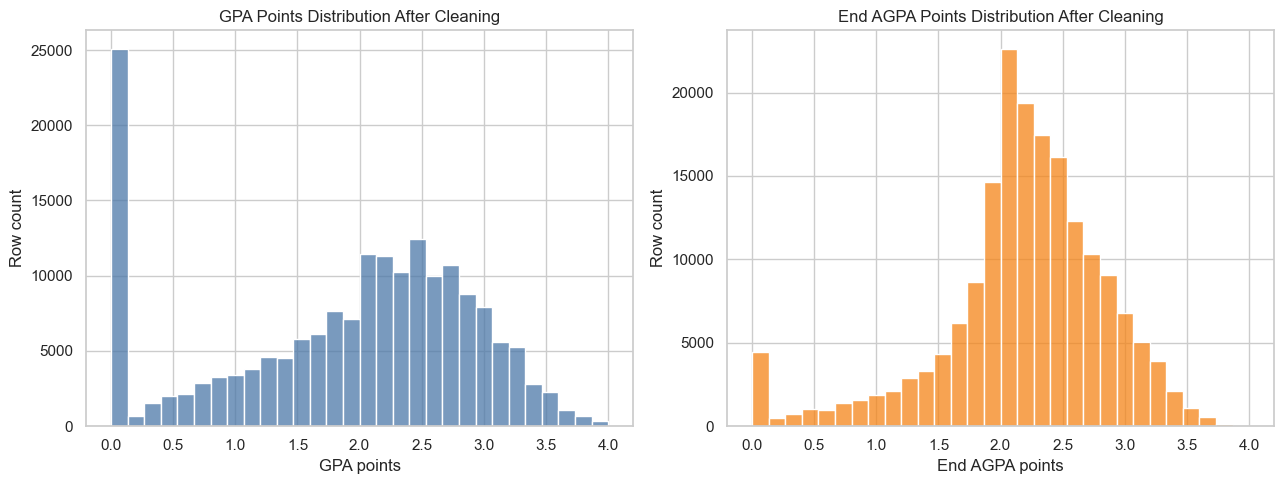

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df_clean, x="gpa_points", bins=30, color="#4C78A8", ax=axes[0])
axes[0].set_title("GPA Points Distribution After Cleaning")
axes[0].set_xlabel("GPA points")
axes[0].set_ylabel("Row count")

sns.histplot(data=df_clean, x="end_agpa_points", bins=30, color="#F58518", ax=axes[1])
axes[1].set_title("End AGPA Points Distribution After Cleaning")
axes[1].set_xlabel("End AGPA points")
axes[1].set_ylabel("Row count")

plt.tight_layout()
plt.show()

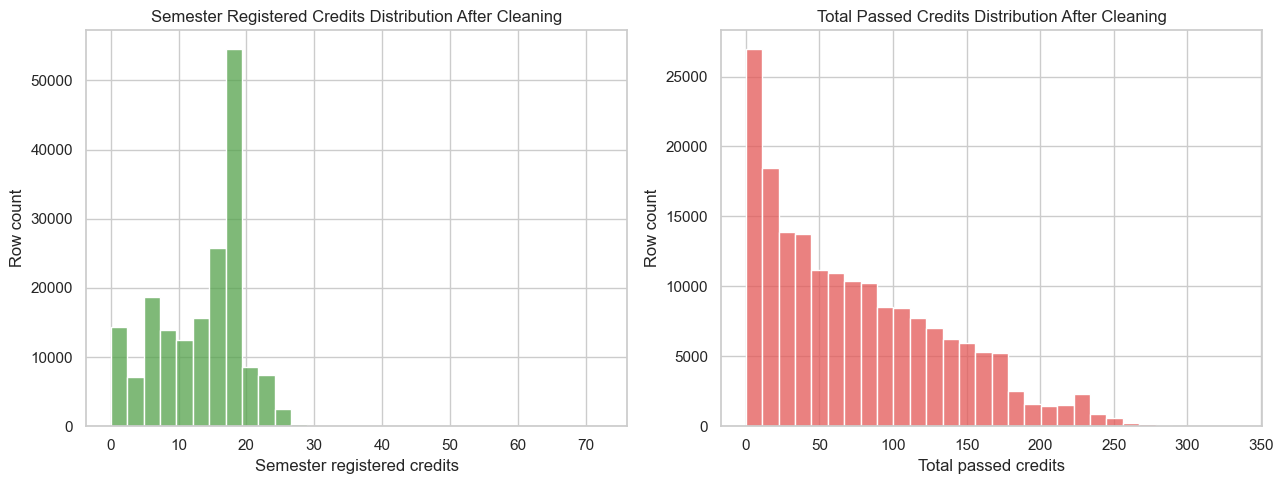

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df_clean, x="semester_reg_credits", bins=30, color="#54A24B", ax=axes[0])
axes[0].set_title("Semester Registered Credits Distribution After Cleaning")
axes[0].set_xlabel("Semester registered credits")
axes[0].set_ylabel("Row count")

sns.histplot(data=df_clean, x="total_pass_credits", bins=30, color="#E45756", ax=axes[1])
axes[1].set_title("Total Passed Credits Distribution After Cleaning")
axes[1].set_xlabel("Total passed credits")
axes[1].set_ylabel("Row count")

plt.tight_layout()
plt.show()

## Final displays

The clean table is available as `df_clean`. Audit reports are available as `dropped_permanent_status_report`, `dropped_degree_null_report`, `dropped_withdrawn_single_zero_activity_report`, and `dropped_core_null_report`.

In [25]:
display(df_clean.head())

df_clean.info()

display(dropped_permanent_status_report.head())
display(dropped_degree_null_report.head())
display(dropped_withdrawn_single_zero_activity_report.head())
display(dropped_core_null_report.head())

,student_status_id,student_id,part_id,degree_id,start_part_id,finish_part_id,grade_version_id,prev_gpa_points,prev_gpa_percent,gpa_points,gpa_percent,start_agpa_points,start_agpa_percent,end_agpa_points,end_agpa_percent,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,semester_in_courses,semester_in_credits,start_total_in_courses,start_total_in_credits,end_total_in_courses,end_total_in_credits,total_semesters,reg_total_semesters,total_reg_courses,total_reg_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,finish_status,version_title_sl,degree_name_sl,degree_credits_count,start_level_id,start_level_name_pl
0,297550.111,48.111,20203,22.111,20203,20212,3.111,0.0,0.0,0.0,0.0,0.97,39.4,0.93,38.6,2.0,4.0,0.0,0.0,2.0,4.0,0.0,0.0,26.0,66.0,26.0,66.0,16.0,12.0,73.0,180.0,26.0,66.0,47.0,114.0,CLOSE_FILE,القرار رقم 230,إدارة (اختصاص عام),72.0,692.111,Third year
1,314343.111,48.111,20211,22.111,20203,20212,3.111,0.0,0.0,0.0,0.0,0.93,38.6,0.93,38.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,66.0,26.0,66.0,17.0,12.0,75.0,184.0,26.0,66.0,49.0,118.0,CLOSE_FILE,القرار رقم 230,إدارة (اختصاص عام),72.0,692.111,Third year
2,320948.111,48.111,20212,22.111,20203,20212,3.111,0.0,0.0,0.0,0.0,0.93,38.6,0.93,38.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,66.0,26.0,66.0,18.0,12.0,75.0,184.0,26.0,66.0,49.0,118.0,CLOSE_FILE,القرار رقم 230,إدارة (اختصاص عام),72.0,692.111,Third year
3,114381.111,128.111,20111,19.111,20111,20151,2.111,<NA>,<NA>,1.57,51.4,0.0,20.0,1.57,51.4,7.0,17.0,5.0,13.0,2.0,4.0,5.0,13.0,0.0,0.0,5.0,13.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,CLOSE_FILE,القرار الوزاري الموحد,إدارة الأعمال,148.0,99.111,First Year
4,114382.111,128.111,20112,19.111,20111,20151,2.111,1.57,51.4,0.58,31.6,1.57,51.4,1.06,41.2,8.0,18.0,2.0,5.0,6.0,13.0,2.0,5.0,5.0,13.0,7.0,18.0,2.0,2.0,7.0,17.0,5.0,13.0,2.0,4.0,CLOSE_FILE,القرار الوزاري الموحد,إدارة الأعمال,148.0,99.111,First Year


<class 'pandas.DataFrame'>
Index: 181552 entries, 0 to 184529
Data columns (total 41 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   student_status_id       181552 non-null  string 
 1   student_id              181552 non-null  string 
 2   part_id                 181552 non-null  Int64  
 3   degree_id               181552 non-null  string 
 4   start_part_id           181552 non-null  Int64  
 5   finish_part_id          116981 non-null  Int64  
 6   grade_version_id        181552 non-null  string 
 7   prev_gpa_points         164480 non-null  Float64
 8   prev_gpa_percent        164480 non-null  Float64
 9   gpa_points              181552 non-null  Float64
 10  gpa_percent             181552 non-null  Float64
 11  start_agpa_points       181552 non-null  Float64
 12  start_agpa_percent      181552 non-null  Float64
 13  end_agpa_points         181552 non-null  Float64
 14  end_agpa_percent        181552 non-n

,student_status_id,student_id,part_id,degree_id,start_part_id,finish_part_id,grade_version_id,permanent_status_id,permanent_status_sl,study_mode,prev_gpa_points,prev_gpa_percent,gpa_percent,gpa_points,start_agpa_percent,start_agpa_points,start_total_in_courses,start_total_in_credits,end_total_in_courses,end_total_in_credits,end_agpa_percent,end_agpa_points,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,semester_in_courses,semester_in_credits,total_semesters,total_reg_courses,total_reg_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,reg_total_semesters,finish_status,version_title_sl,degree_name_sl,degree_credits_count,start_level_id,start_level_name_pl
90907,247204.111,12910.111,20172,10.111,20173,20201,3.111,16,قيد التسجيل - تسجيل مباشر,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GRADUATED,القرار رقم 230,إدارة المؤسسات المالية و المصرفية,134.0,525.111,First Year
90916,249680.111,12911.111,20172,8.111,20173,20222,3.111,16,قيد التسجيل - تسجيل مباشر,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GRADUATED,القرار رقم 230,اداره الموارد البشرية,134.0,535.111,First Year
90931,249727.111,12912.111,20172,8.111,20173,20203,3.111,16,قيد التسجيل - تسجيل مباشر,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GRADUATED,القرار رقم 230,اداره الموارد البشرية,134.0,535.111,First Year
90988,251410.111,12916.111,20173,2.111,20181,20232,3.111,16,قيد التسجيل - تسجيل مباشر,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GRADUATED,القرار رقم 230,دكتور في الطب,251.0,7.111,First Year
100366,259794.111,13641.111,20181,3.111,20182,20231,3.111,16,قيد التسجيل - تسجيل مباشر,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GRADUATED,القرار رقم 230,هندسة البرمجيات ونظم المعلومات,170.0,667.111,First Year


,student_status_id,student_id,part_id,degree_id,start_part_id,finish_part_id,grade_version_id,permanent_status_id,permanent_status_sl,study_mode,prev_gpa_points,prev_gpa_percent,gpa_percent,gpa_points,start_agpa_percent,start_agpa_points,start_total_in_courses,start_total_in_credits,end_total_in_courses,end_total_in_credits,end_agpa_percent,end_agpa_points,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,semester_in_courses,semester_in_credits,total_semesters,total_reg_courses,total_reg_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,reg_total_semesters,finish_status,version_title_sl,degree_name_sl,degree_credits_count,start_level_id,start_level_name_pl
117872,301457.111,15096.111,20202,<NA>,20201,<NA>,3.111,40,راسب مفاضلة,C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,القرار رقم 230,<NA>,<NA>,<NA>,First Year
134488,333909.111,18001.111,20221,<NA>,20211,<NA>,3.111,40,راسب مفاضلة,C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,القرار رقم 230,<NA>,<NA>,<NA>,First Year
134624,301746.111,18063.111,20211,<NA>,20211,<NA>,3.111,40,راسب مفاضلة,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,القرار رقم 230,<NA>,<NA>,<NA>,First Year
134719,301779.111,18096.111,20211,<NA>,20211,<NA>,3.111,40,راسب مفاضلة,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,القرار رقم 230,<NA>,<NA>,<NA>,First Year
134736,301789.111,18106.111,20211,<NA>,20211,<NA>,3.111,40,راسب مفاضلة,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,القرار رقم 230,<NA>,<NA>,<NA>,First Year


,student_status_id,student_id,part_id,degree_id,start_part_id,finish_part_id,grade_version_id,permanent_status_id,permanent_status_sl,study_mode,prev_gpa_points,prev_gpa_percent,gpa_percent,gpa_points,start_agpa_percent,start_agpa_points,start_total_in_courses,start_total_in_credits,end_total_in_courses,end_total_in_credits,end_agpa_percent,end_agpa_points,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,semester_in_courses,semester_in_credits,total_semesters,total_reg_courses,total_reg_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,reg_total_semesters,finish_status,version_title_sl,degree_name_sl,degree_credits_count,start_level_id,start_level_name_pl
2912,214334.111,1542.111,20131,22.111,20131,20130,3.111,9,منسحب,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WITHDRAWN,القرار رقم 230,إدارة (اختصاص عام),72.0,109.111,First Year
8763,205769.111,3269.111,20131,13.111,20131,20130,3.111,9,منسحب,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WITHDRAWN,القرار رقم 230,الصيدلة و الكيمياء الصيدلية,178.0,29.111,First Year
18981,205772.111,5747.111,20131,21.111,20131,20130,3.111,9,منسحب,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WITHDRAWN,القرار رقم 230,هندسة حاسوب (اختصاص عام),86.0,59.111,First Year
19114,160114.111,5756.111,20131,21.111,20131,20131,3.111,9,منسحب,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,WITHDRAWN,القرار رقم 230,هندسة حاسوب (اختصاص عام),86.0,59.111,First Year
25570,214982.111,7578.111,20131,1.111,20131,20130,3.111,9,منسحب,C,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WITHDRAWN,القرار رقم 230,دكتور في طب الأسنان,185.0,19.111,First Year


,student_status_id,student_id,part_id,degree_id,start_part_id,finish_part_id,grade_version_id,permanent_status_id,permanent_status_sl,study_mode,prev_gpa_points,prev_gpa_percent,gpa_percent,gpa_points,start_agpa_percent,start_agpa_points,start_total_in_courses,start_total_in_credits,end_total_in_courses,end_total_in_credits,end_agpa_percent,end_agpa_points,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,semester_in_courses,semester_in_credits,total_semesters,total_reg_courses,total_reg_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,reg_total_semesters,finish_status,version_title_sl,degree_name_sl,degree_credits_count,start_level_id,start_level_name_pl


In [26]:
df_clean.to_parquet(r'D:\AI\Real projects\Academic_Advisor\data\preprocessed\v_add_student_degree_status_clean.parquet', index=False)

In [27]:
df_clean['student_id'].nunique()

17155

In [28]:
df_clean[(df_clean['finish_status']=='WITHDRAWN')&(df_clean['gpa_points']==0)&(df_clean['prev_gpa_points']==0)]

,student_status_id,student_id,part_id,degree_id,start_part_id,finish_part_id,grade_version_id,prev_gpa_points,prev_gpa_percent,gpa_points,gpa_percent,start_agpa_points,start_agpa_percent,end_agpa_points,end_agpa_percent,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,semester_in_courses,semester_in_credits,start_total_in_courses,start_total_in_credits,end_total_in_courses,end_total_in_credits,total_semesters,reg_total_semesters,total_reg_courses,total_reg_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,finish_status,version_title_sl,degree_name_sl,degree_credits_count,start_level_id,start_level_name_pl
162,267095.111,139.111,20182,22.111,20172,20191,2.111,0.0,0.0,0.0,0.0,0.33,26.6,0.33,26.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,21.0,10.0,21.0,17.0,12.0,72.0,177.0,14.0,34.0,57.0,140.0,WITHDRAWN,القرار الوزاري الموحد,إدارة (اختصاص عام),72.0,505.111,First Year
163,275429.111,139.111,20191,22.111,20172,20191,2.111,0.0,0.0,0.0,0.0,0.33,26.6,0.33,26.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,21.0,10.0,21.0,18.0,12.0,72.0,177.0,14.0,34.0,57.0,140.0,WITHDRAWN,القرار الوزاري الموحد,إدارة (اختصاص عام),72.0,829.111,First Year
167,203132.111,140.111,20122,19.111,20111,20151,2.111,0.0,0.0,0.0,0.0,1.48,49.6,1.48,49.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,20.0,8.0,20.0,4.0,2.0,13.0,30.0,8.0,20.0,5.0,10.0,WITHDRAWN,القرار الوزاري الموحد,إدارة الأعمال,148.0,100.111,Second Year
172,137355.111,140.111,20151,19.111,20111,20151,2.111,0.0,0.0,0.0,0.0,1.61,52.2,1.61,52.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,61.0,24.0,61.0,9.0,6.0,39.0,96.0,24.0,61.0,16.0,37.0,WITHDRAWN,القرار الوزاري الموحد,إدارة الأعمال,148.0,101.111,Third year
296,214966.111,149.111,20142,19.111,20111,20142,2.111,0.0,0.0,0.0,0.0,3.02,80.4,3.02,80.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,114.0,45.0,114.0,8.0,6.0,45.0,114.0,45.0,114.0,0.0,0.0,WITHDRAWN,القرار الوزاري الموحد,إدارة الأعمال,148.0,102.111,Fourth Year
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180808,389898.111,31663.111,20243,41.111,20242,20252,3.111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,6.0,0.0,0.0,2.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,6.0,16.0,0.0,0.0,1.0,2.0,WITHDRAWN,القرار رقم 230,دكتور في الطب 2023,251.0,1974.111,First Year
180809,394424.111,31663.111,20251,41.111,20242,20252,3.111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,12.0,0.0,0.0,4.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,8.0,22.0,0.0,0.0,3.0,8.0,WITHDRAWN,القرار رقم 230,دكتور في الطب 2023,251.0,1974.111,First Year
180810,412292.111,31663.111,20252,41.111,20242,20252,3.111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,12.0,34.0,0.0,0.0,7.0,20.0,WITHDRAWN,القرار رقم 230,دكتور في الطب 2023,251.0,1974.111,First Year
182551,412553.111,32525.111,20252,61.111,20251,20252,3.111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,6.0,18.0,0.0,0.0,2.0,6.0,WITHDRAWN,القرار رقم 230,هندسة الذكاء الاصطناعي/هندسة الاتصالات الذكية,180.0,<NA>,First Year


In [29]:
withdrawn_one_record_students = (
    df_clean[df_clean["finish_status"].eq("WITHDRAWN")]
    .groupby("student_id")
    .size()
)

num_withdrawn_students_with_one_record = (withdrawn_one_record_students == 1).sum()

print("WITHDRAWN students with exactly one record:", num_withdrawn_students_with_one_record)

WITHDRAWN students with exactly one record: 41


## Drop students that exist in ADD_STUDENT_DEGREE_STATUS but do not exist in CRG_STUDENT_COURSE.
These students have no course history and are not useful for the academic recommendation/training dataset.
Create dropped_only_in_add_report.
Collect their student_status_id values.
## Drop rows using student_status_id, not DataFrame index.

In [31]:
# ==============================
# Compare unique students between CRG_STUDENT_COURSE and ADD_STUDENT_DEGREE_STATUS
# ==============================
df_crg=pd.read_parquet(r"D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\clean_v_crg_student_course.parquet")
crg_students = set(df_crg["student_id"].dropna().unique())
add_students = set(df_clean["student_id"].dropna().unique())

students_in_both = crg_students & add_students
only_in_crg = crg_students - add_students
only_in_add = add_students - crg_students

print("========== STUDENT LEVEL OVERLAP ==========")
print("CRG unique students:", len(crg_students))
print("ADD unique students:", len(add_students))
print("Students in both:", len(students_in_both))
print("Only in CRG:", len(only_in_crg))
print("Only in ADD:", len(only_in_add))

print("\nCRG extra over ADD:", len(crg_students) - len(add_students))

========== STUDENT LEVEL OVERLAP ==========
CRG unique students: 16171
ADD unique students: 17155
Students in both: 16171
Only in CRG: 0
Only in ADD: 984

CRG extra over ADD: -984


In [32]:
only_in_add_df = (
    df_clean[df_clean["student_id"].isin(only_in_add)]
    .sort_values("student_id")
)

display(only_in_add_df.head(100))

,student_status_id,student_id,part_id,degree_id,start_part_id,finish_part_id,grade_version_id,prev_gpa_points,prev_gpa_percent,gpa_points,gpa_percent,start_agpa_points,start_agpa_percent,end_agpa_points,end_agpa_percent,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,semester_in_courses,semester_in_credits,start_total_in_courses,start_total_in_credits,end_total_in_courses,end_total_in_credits,total_semesters,reg_total_semesters,total_reg_courses,total_reg_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,finish_status,version_title_sl,degree_name_sl,degree_credits_count,start_level_id,start_level_name_pl
49266,203892.111,10004.111,20151,2.111,20151,20152,3.111,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,7.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,WITHDRAWN,القرار رقم 230,دكتور في الطب,251.0,7.111,First Year
49267,209267.111,10004.111,20152,2.111,20151,20152,3.111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,7.0,21.0,0.0,0.0,0.0,0.0,WITHDRAWN,القرار رقم 230,دكتور في الطب,251.0,7.111,First Year
49288,136124.111,10006.111,20151,22.111,20151,20152,3.111,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,8.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,WITHDRAWN,القرار رقم 230,إدارة (اختصاص عام),72.0,109.111,First Year
49289,209577.111,10006.111,20152,22.111,20151,20152,3.111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,8.0,18.0,0.0,0.0,0.0,0.0,WITHDRAWN,القرار رقم 230,إدارة (اختصاص عام),72.0,109.111,First Year
49424,203988.111,10016.111,20151,21.111,20151,20152,3.111,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,6.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,WITHDRAWN,القرار رقم 230,هندسة حاسوب (اختصاص عام),86.0,59.111,First Year
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76037,235145.111,11815.111,20171,2.111,20171,20171,3.111,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CANCEL_ADMISSION,القرار رقم 230,دكتور في الطب,251.0,415.111,First Year
76351,235168.111,11838.111,20171,13.111,20171,20171,3.111,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CANCEL_ADMISSION,القرار رقم 230,الصيدلة و الكيمياء الصيدلية,178.0,446.111,First Year
76713,235193.111,11863.111,20171,22.111,20171,20171,3.111,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CANCEL_ADMISSION,القرار رقم 230,إدارة (اختصاص عام),72.0,505.111,First Year
76877,235209.111,11878.111,20171,13.111,20171,20171,3.111,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CANCEL_ADMISSION,القرار رقم 230,الصيدلة و الكيمياء الصيدلية,178.0,446.111,First Year


In [33]:
only_in_add_df["finish_status"].value_counts(dropna=False)

finish_status
CLOSE_FILE          701
CANCEL_ADMISSION    604
<NA>                212
WITHDRAWN           191
Name: count, dtype: int64[pyarrow]

In [34]:
only_in_add_df['student_id'].nunique()

984

In [35]:
# ============================================
# Drop students that exist only in ADD, not in CRG
# using student_status_id
# ============================================

# 1. Unique students in each table
crg_students = set(df_crg["student_id"].dropna().unique())
add_students = set(df_clean["student_id"].dropna().unique())

# 2. Students found only in ADD_STUDENT_DEGREE_STATUS
only_in_add_students = add_students - crg_students

print("Students only in ADD:", len(only_in_add_students))

# 3. Rows in ADD that belong to those students
only_in_add_mask = df_clean["student_id"].isin(only_in_add_students)

dropped_only_in_add_report = df_clean.loc[only_in_add_mask].copy()

print("Rows to drop only-in-ADD:", len(dropped_only_in_add_report))
print("Unique students to drop only-in-ADD:", dropped_only_in_add_report["student_id"].nunique())

print("\nfinish_status distribution:")
print(dropped_only_in_add_report["finish_status"].value_counts(dropna=False))

# 4. Save stable row IDs to drop
only_in_add_student_status_ids_to_drop = (
    dropped_only_in_add_report["student_status_id"]
    .dropna()
    .unique()
)

print("student_status_id values to drop:", len(only_in_add_student_status_ids_to_drop))

# 5. Drop using student_status_id, not index
df_add_clean_step = df_clean.loc[
    ~df_clean["student_status_id"].isin(only_in_add_student_status_ids_to_drop)
].copy()

print("Shape before:", df_clean.shape)
print("Shape after:", df_add_clean_step.shape)

# 6. Validation
assert not df_add_clean_step["student_status_id"].isin(only_in_add_student_status_ids_to_drop).any()

Students only in ADD: 984
Rows to drop only-in-ADD: 1708
Unique students to drop only-in-ADD: 984

finish_status distribution:
finish_status
CLOSE_FILE          701
CANCEL_ADMISSION    604
<NA>                212
WITHDRAWN           191
Name: count, dtype: int64[pyarrow]
student_status_id values to drop: 1708
Shape before: (181552, 41)
Shape after: (179844, 41)


In [36]:
display(
    dropped_only_in_add_report
    .groupby("finish_status", dropna=False)
    .agg(
        rows=("student_id", "size"),
        unique_students=("student_id", "nunique"),
        total_reg_courses_sum=("total_reg_courses", "sum"),
        total_reg_credits_sum=("total_reg_credits", "sum"),
        total_pass_courses_sum=("total_pass_courses", "sum"),
        total_pass_credits_sum=("total_pass_credits", "sum"),
        total_fail_courses_sum=("total_fail_courses", "sum"),
        total_fail_credits_sum=("total_fail_credits", "sum"),
    )
)

,rows,unique_students,total_reg_courses_sum,total_reg_credits_sum,total_pass_courses_sum,total_pass_credits_sum,total_fail_courses_sum,total_fail_credits_sum
finish_status,,,,,,,,
CANCEL_ADMISSION,604,604,0.0,0.0,0.0,0.0,0.0,0.0
CLOSE_FILE,701,166,1847.0,5162.0,143.0,436.0,1003.0,2800.0
WITHDRAWN,191,92,556.0,1581.0,27.0,84.0,176.0,511.0
<NA>,212,122,695.0,2064.0,104.0,316.0,162.0,555.0


In [37]:
df_clean['student_id'].nunique()

17155

In [38]:
# ============================================================
# Drop students existing only in ADD_STUDENT_DEGREE_STATUS clean table
# and not existing in CRG_STUDENT_COURSE
# Drop by student_status_id, not by index
# ============================================================

# 1. Get unique students from each table
crg_students = set(df_crg["student_id"].dropna().unique())
add_students = set(df_clean["student_id"].dropna().unique())

# 2. Students found in ADD/status table but not in CRG/course table
only_in_add_students = add_students - crg_students

print("Unique students in CRG:", len(crg_students))
print("Unique students in df_clean:", len(add_students))
print("Students only in df_clean / ADD:", len(only_in_add_students))

# 3. Find rows in df_clean that belong to only-in-ADD students
only_in_add_mask = df_clean["student_id"].isin(only_in_add_students)

# 4. Save dropped rows in a report before deleting
dropped_only_in_add_report = df_clean.loc[only_in_add_mask].copy()

print("Rows to drop:", len(dropped_only_in_add_report))
print("Unique students to drop:", dropped_only_in_add_report["student_id"].nunique())

print("\nfinish_status distribution of dropped rows:")
print(dropped_only_in_add_report["finish_status"].value_counts(dropna=False))

# 5. Collect stable primary keys to drop
student_status_ids_to_drop = (
    dropped_only_in_add_report["student_status_id"]
    .dropna()
    .unique()
)

print("\nstudent_status_id rows to drop:", len(student_status_ids_to_drop))

# 6. Drop using student_status_id
df_clean = df_clean.loc[
    ~df_clean["student_status_id"].isin(student_status_ids_to_drop)
].copy()

# 7. Validation
assert not df_clean["student_status_id"].isin(student_status_ids_to_drop).any(), \
    "Some dropped student_status_id values still exist in df_clean."

print("\nFinal df_clean shape:", df_clean.shape)
print("Remaining unique students:", df_clean["student_id"].nunique())

Unique students in CRG: 16171
Unique students in df_clean: 17155
Students only in df_clean / ADD: 984
Rows to drop: 1708
Unique students to drop: 984

finish_status distribution of dropped rows:
finish_status
CLOSE_FILE          701
CANCEL_ADMISSION    604
<NA>                212
WITHDRAWN           191
Name: count, dtype: int64[pyarrow]

student_status_id rows to drop: 1708

Final df_clean shape: (179844, 41)
Remaining unique students: 16171


In [39]:
df_clean.to_parquet(r"D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_ADD_STUDENT_DEGREE_STATUS\clean_v_add_student_degree_status.parquet", index=False)

In [40]:
df_clean['student_id'].nunique()

16171

In [41]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 179844 entries, 0 to 184528
Data columns (total 41 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   student_status_id       179844 non-null  string 
 1   student_id              179844 non-null  string 
 2   part_id                 179844 non-null  Int64  
 3   degree_id               179844 non-null  string 
 4   start_part_id           179844 non-null  Int64  
 5   finish_part_id          115488 non-null  Int64  
 6   grade_version_id        179844 non-null  string 
 7   prev_gpa_points         163750 non-null  Float64
 8   prev_gpa_percent        163750 non-null  Float64
 9   gpa_points              179844 non-null  Float64
 10  gpa_percent             179844 non-null  Float64
 11  start_agpa_points       179844 non-null  Float64
 12  start_agpa_percent      179844 non-null  Float64
 13  end_agpa_points         179844 non-null  Float64
 14  end_agpa_percent        179844 non-n